In [2]:
import sys

sys.path.append("../")
sys.path.append("../../")
sys.path.append("../../../")

import os
import re
from pathlib import Path

import numpy as np
from dotenv import load_dotenv

load_dotenv()
tcr_toolbox_data_path = os.getenv("tcr_toolbox_data_path")

from tcr_toolbox.sequencing_analysis_PRIVATE.plate_tcr_epi_count_analysis import (
    add_tcr_epi_pairs_only_supported_by_co_occurrence_bool_col,
    add_pair_entropy_over_plate_col,
    calculate_tcr_epi_pair_exp_prob_matrix,
    filter_UMI_counts_df_dict,
    init_umi_count_analysis_dir,
    obs_tcr_epi_count_binom_sf_test,
    plot_detected_tcr_epi_plate_map,
    plot_pvalue_corrected_rank_vs_pvalue_corrected,
    plot_tcr_epi_pair_ma_plot,
    read_tcr_epi_pair_counts_csv,
    read_umi_count_tsv,
    write_reactive_pair_results,
    write_tcr_epi_pair_well_count_files,
)
from tcr_toolbox.sequencing_analysis.utils import overlap_between_ref_and_count_names, read_gdna_counts_csv
from tcr_toolbox.utils.plot_utils import plot_count_histogram, set_mpl_params, startfig
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl, mylines = set_mpl_params(mpl=mpl)
from tcr_toolbox.utils.stat_utils import normalize_counts_df_by_total_counts
import pandas as pd
from scipy.stats import spearmanr

In [ ]:
project_dir = "/data/mel-pt-d_100_TCR_500_minimal_peptide_pairscan"

In [4]:
init_umi_count_analysis_dir(project_dir)

In [98]:
counts_df_dict = read_umi_count_tsv(project_dir=project_dir, plate_name_split_location=0)

Reading plate: 14v1
Reading plate: 3v4
Reading plate: 4v4
Reading plate: 11v3
Reading plate: 13v4
Reading plate: 2v4
Reading plate: 10v4
Reading plate: 12v4
Reading plate: 8v4
Reading plate: 1v4
Reading plate: 6v4
Reading plate: 9v4
Reading plate: 5v2
Reading plate: 7v4


In [ ]:
epi_umi_threshold_dict = {
    "1v4":300, 
    "2v4":300, 
    "3v4":200, 
    "4v4":300, 
    "5v2":350, 
    "6v4":300,
    "7v4":200,
    "8v4":300, 
    "9v4":300,
    "10v4":300, 
    "11v3":300, 
    "12v4":300, 
    "13v4":300, 
    "14v1":200, 
}

tcr_umi_threshold_dict = {
    "1v4":80,
    "2v4":150,
    "3v4":150, 
    "4v4":150,
    "5v2":600,
    "6v4":35, 
    "7v4":15,
    "8v4":250, 
    "9v4":250, 
    "10v4":70, 
    "11v3":200, 
    "12v4":25, 
    "13v4":100, 
    "14v1":15, 
}


min_start_fraction_of_top_umi_count_dict = {
    "1v4":1.6,  
    "2v4":1.7, 
    "3v4":2.0,  
    "4v4":2.1, 
    "5v2":2.1, 
    "6v4":1.75,  
    "7v4":1.3, 
    "8v4":1.6,  
    "9v4":2.2, 
    "10v4":1.8, 
    "11v3":1.9, 
    "12v4":1.7, 
    "13v4":2.1, 
    "14v1":2.0, 
}

min_end_fraction_of_top_umi_count_dict = {
    "1v4":0.04,
    "2v4":0.05, 
    "3v4":0.04, 
    "4v4":0.06,
    "5v2":0.06,
    "6v4":0.03, 
    "7v4":0.03, 
    "8v4":0.04, 
    "9v4":0.04, 
    "10v4":0.04, 
    "11v3":0.05, 
    "12v4":0.04, 
    "13v4":0.04, 
    "14v1":0.05, 
}

In [ ]:
counts_df_dict = filter_UMI_counts_df_dict(
    project_dir = project_dir, 
    counts_df_dict = counts_df_dict, 
    epi_umi_threshold=epi_umi_threshold_dict, 
    tcr_umi_threshold=tcr_umi_threshold_dict,
    min_start_fraction_of_top_umi_count = min_start_fraction_of_top_umi_count_dict,
    min_end_fraction_of_top_umi_count = min_end_fraction_of_top_umi_count_dict, 
    num_bins=50
)

Filtering plate: 14v1
Number of unique epis: 304
Number of unique tcrs: 27
Filtering plate: 3v4
Number of unique epis: 277
Number of unique tcrs: 37
Filtering plate: 4v4
Number of unique epis: 298
Number of unique tcrs: 54
Filtering plate: 11v3
Number of unique epis: 258
Number of unique tcrs: 39
Filtering plate: 13v4
Number of unique epis: 297
Number of unique tcrs: 55
Filtering plate: 2v4
Number of unique epis: 283
Number of unique tcrs: 46
Filtering plate: 10v4
Number of unique epis: 323
Number of unique tcrs: 45
Filtering plate: 12v4
Number of unique epis: 277
Number of unique tcrs: 40
Filtering plate: 8v4
Number of unique epis: 290
Number of unique tcrs: 41
Filtering plate: 1v4
Number of unique epis: 312
Number of unique tcrs: 50
Filtering plate: 6v4
Number of unique epis: 324
Number of unique tcrs: 48
Filtering plate: 9v4
Number of unique epis: 292
Number of unique tcrs: 60
Filtering plate: 5v2
Number of unique epis: 126
Number of unique tcrs: 33
Filtering plate: 7v4
Number of un

In [9]:
plot_detected_tcr_epi_plate_map(project_dir=project_dir, counts_df_dict=counts_df_dict, validating_pair_dict=None, epitope_barcode_length=18, detected_fontsize=3)

Plotting plate: 14v1
Plotting plate: 3v4
Plotting plate: 4v4
Plotting plate: 11v3
Plotting plate: 13v4
Plotting plate: 2v4
Plotting plate: 10v4
Plotting plate: 12v4
Plotting plate: 8v4
Plotting plate: 1v4
Plotting plate: 6v4
Plotting plate: 9v4
Plotting plate: 5v2
Plotting plate: 7v4


In [ ]:
write_tcr_epi_pair_well_count_files(
    project_dir=project_dir,
    plates_list=list(counts_df_dict.keys()),
    plates_list_name="mel-pt-d",
    counts_df_dict=counts_df_dict.copy(),
    collapse_tcr_technical_duplicates=True,
    reference_file='/references/r2_beta_mel-pt-d_500_min_epi.fa',
    collapse_epitope_barcode=True,
    epitope_barcode_length=36,
    validating_pair_dict=None,
)

Processing plate: 14v1
Processing plate: 3v4
Processing plate: 4v4
Processing plate: 11v3
Processing plate: 13v4
Processing plate: 2v4
Processing plate: 10v4
Processing plate: 12v4
Processing plate: 8v4
Processing plate: 1v4
Processing plate: 6v4
Processing plate: 9v4
Processing plate: 5v2
Processing plate: 7v4
Writing patient-D summary statistics...
Total # of co-culture sort wells counted: 5071


## Bulk_seq_data

In [29]:
name_split_location = 3

In [ ]:
bulk_project_dir = Path('/data/mel-pt-d_100_TCR_500_minimal_peptide_pairscan/bulk_seq_data/epi')

In [ ]:
for count_file in (bulk_project_dir / "counts").glob("*.csv"):
    print(count_file.name)

    overlap_between_ref_and_count_names(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        reference_file='/references/500_min_epi.fa',
        library_ref_id_list=None,
        print_diff_names=True,
    )

    outs_dir = Path(bulk_project_dir) / "outs"
    outs_dir.mkdir(parents=True, exist_ok=True)

    plot_count_histogram(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        count_file_count_col="read_count",
        bin_min=0,
        bin_max=5,
        bin_size=0.1,
        log10 = True, 
        xlabel="Number of reads per transcript",
        percentile_ratio_filter_threshold = 2, 
        title=count_file.stem.split("_")[name_split_location],
        save_file_path=outs_dir / f"{count_file.stem.split('_')[name_split_location]}_count_hist.pdf",
        ylim_max=75,
        w=6.25,
        h=6.25,
    )
    print("\n")

In [ ]:
bulk_project_dir = Path('/data/mel-pt-d_100_TCR_500_minimal_peptide_pairscan/bulk_seq_data/tcr')

In [ ]:
# Note: This TCR reference file contains all TCRs from Mel-Pt-D, while we made a library of only 100 TCRs and we manually verified that 96% of TCRS were successfully assembled. 
for count_file in (bulk_project_dir / "counts").glob("*.csv"):
    print(count_file.name)
   
    overlap_between_ref_and_count_names(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        reference_file='/references/r2_beta_mel-pt-d_500_min_epi.fa',
        library_ref_id_list=None,
        print_diff_names=True,
    )

    outs_dir = Path(bulk_project_dir) / "outs"
    outs_dir.mkdir(parents=True, exist_ok=True)

    plot_count_histogram(
        count_file=count_file,
        count_file_ref_name_col="reference_name",
        count_file_count_col="read_count",
        bin_min=0,
        bin_max=5,
        bin_size=0.1,
        log10 = True, 
        xlabel="Number of reads per transcript",
        percentile_ratio_filter_threshold = 2, 
        title=count_file.stem.split("_")[name_split_location],
        save_file_path=outs_dir / f"{count_file.stem.split('_')[name_split_location]}_count_hist.pdf",
        ylim_max=60,
        w=6.25,
        h=6.25,
    )
    print("\n")

## Mel-Pt-D 500 minimal peptides VS 100 TCRs PAIR-Scan analysis 

In [ ]:
# After individual TCR-Ag pair validation co-cultures, code can be re-run with a validating_pair_dict to color annotate dots in results plots. 
validating_pair_dict = {
    "epi_ADAM15_FR250LW_651_9_14_A0201-tcr_1_5_A3_2_CD8_mel-pt-d_1":True, 
    "epi_ADAM15_FR250LW_651_9_14_A0201-tcr_1_5_E7_54_CD8_mel-pt-d_1":True, 
    "epi_SATB2_D517N_1778_9_8_A0201-tcr_1_5_F2_61_CD8_mel-pt-d_1":True, 
    "epi_HSPA8_P101L_3_9_8_A0301-tcr_1_5_G3_74_CD8_mel-pt-d_1":True, 
    "epi_SIL1_E280K_763_9_7_A0301-tcr_1_5_E22_153_CD8_mel-pt-d_2":False, 
    "epi_ZNF638_S1183F_481_9_10_B5101-tcr_1_5_D7_42_CD8_mel-pt-d_1":False, 
    "epi_MAP4K3_P480L_893_9_10_B0702-tcr_1_5_B5_16_CD8_mel-pt-d_1":False, 
    "epi_FIG4_S827L_1622_9_14_A0201-tcr_1_5_B11_22_CD8_mel-pt-d_1":False, 
    "epi_DAB2_P547S_89_8_12_B5101-tcr_1_5_A10_9_CD8_mel-pt-d_1":False, 
    "epi_IGSF8_S427F_1115_9_15_C0702-tcr_1_5_A7_6_CD8_mel-pt-d_1":False, 
    "epi_IGSF8_S427F_1115_9_15_C0702-tcr_1_5_D12_47_CD8_mel-pt-d_1":False, 
    "epi_IGSF8_S427F_1115_9_15_C0702-tcr_1_5_F6_65_CD8_mel-pt-d_1":False, 
    "epi_RSL1D1_P477L_87_11_9_A0301-tcr_1_5_G7_78_CD8_mel-pt-d_1":False, 
    "epi_LTA4H_S416F_271_10_8_A0301-tcr_1_5_B23_118_CD8_mel-pt-d_2":False, 
    "epi_SATB2_D517N_1778_9_8_A0201-tcr_1_5_B10_21_CD8_mel-pt-d_1":False,
}

In [ ]:
project_dir = '/data/mel-pt-d_100_TCR_500_minimal_peptide_pairscan'
plates_list_name = "mel-pt-d"

In [63]:
count_file = Path(project_dir) / "bulk_seq_data" / "epi" / "counts" / "Ag2_B23KCL2LT3_S15_L001_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
epi_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name", collapse_epitope_barcode=True, epitope_barcode_length=18)
normalized_epi_bulk_counts_df = normalize_counts_df_by_total_counts(count_df=epi_bulk_counts_df, count_col="read_count")

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "tcr" / "counts" / "T1_B23KCL2LT3_S16_L001_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
tcr_bulk_counts_df = read_gdna_counts_csv(
    count_file=count_file,
    count_file_ref_name_col="reference_name",
    collapse_tcr_technical_duplicates=False,
)
normalized_tcr_bulk_counts_df = normalize_counts_df_by_total_counts(count_df=tcr_bulk_counts_df, count_col="read_count")

In [65]:
pair_count_matrix_df = read_tcr_epi_pair_counts_csv(pair_count_matrix_csv=Path(project_dir) / "outs" / plates_list_name / f"pair_count_matrix_df_{plates_list_name}.csv")
exp_pair_prob_matrix_df, pair_count_matrix_df = calculate_tcr_epi_pair_exp_prob_matrix(
    pair_count_matrix_df=pair_count_matrix_df,
    normalized_epitope_bulk_counts_df=normalized_epi_bulk_counts_df,
    normalized_tcr_bulk_counts_df=normalized_tcr_bulk_counts_df,
    bulk_epitope_count_col="read_count",
    bulk_tcr_count_col="read_count",
    normalize_using_plate=False,
)

Total called TCR-epitope pair counts: 1725.0
Calculating expected TCR-epitope pair probability matrix using TCR and epitope gDNA bulk sequencing data...
Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!
Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!
Epitope reference name(s) in normalized_epitope_bulk_counts_df that are missing in pair_count_matrix_df: {'epi_SEC31B_P554L_2908_9_14_A0301', 'epi_HECTD4_VL1713VF_1283_9_10_B0702', 'epi_ITSN1_P713L_1432_9_7_C1502', 'epi_STRN_P518L_1436_9_9_C0702', 'epi_COL6A3_G409E_679_9_12_A0301', 'epi_ITGAV_H826Y_885_9_7_A0301', 'epi_ASXL2_S418F_671_9_9_B5101', 'epi_PTPRG_E1118K_1758_9_12_A0301', 'epi_ARID1A_P487S_239_11_10_C0702', 'epi_PLXNC1_R926Q_703_9_8_C1502', 'epi_RANBP17_L895F_1668_9_15_C1502', 'epi_ANKRD17_T1042I_439_9_10_B5101', 'epi_MCC_M77I_2104_9_10_A0201', 'epi_RAB3GAP1_E760K_1025_9_14_A0301', 'epi_HEATR1_R142S_1315_10_9_B5101', 'epi_ABCB5_R461Q_251_9_13_C0702', 'epi_PMEL_P283L_11_9_7_C1502

In [66]:
alpha = 0.75

In [67]:
pair_fold_changes_df = obs_tcr_epi_count_binom_sf_test(
    project_dir=project_dir,
    pair_count_matrix_df=pair_count_matrix_df,
    exp_pair_prob_matrix_df=exp_pair_prob_matrix_df,
    plates_list_name=plates_list_name,
    validating_pair_dict=validating_pair_dict,
    fdr_correction=True,
    alpha=alpha,
    normalize_total_called_pairs=False,
    normalize_total_wells_with_detected_pair=True,
    sort_fold_change=False,
    sort_pvalue=True,
)

1620 TCR-epitope pairs have non-zero well counts of 36818 tested TCR-epitope pairs


In [ ]:
pair_fold_changes_df = add_tcr_epi_pairs_only_supported_by_co_occurrence_bool_col(
    project_dir=project_dir,
    plates_list_name=plates_list_name,
    pair_fold_changes_df=pair_fold_changes_df,
    epi_transcript_ratio=0.275,  
    tcr_transcript_ratio=0.275,  
)

In [69]:
pair_fold_changes_df = add_pair_entropy_over_plate_col(pair_fold_changes_df = pair_fold_changes_df, project_dir = project_dir)

In [ ]:
write_reactive_pair_results(
    pair_fold_changes_df=pair_fold_changes_df,
    project_dir=project_dir,
    plates_list_name=plates_list_name,
)

In [71]:
pair_fold_changes_df.to_excel(Path(project_dir) / "outs" / plates_list_name / f"pair_fold_changes_df_{plates_list_name}.xlsx")

In [ ]:
pair_fold_changes_df = pd.read_excel(Path(project_dir) / "outs" / plates_list_name / f"pair_fold_changes_df_{plates_list_name}.xlsx", index_col = 0)

In [ ]:
plot_tcr_epi_pair_ma_plot(
    pair_fold_changes_df=pair_fold_changes_df,
    title=plates_list_name,
    xlim_max=0.001,
    xticks_list=list(np.arange(-0.00001, 0.0002, 0.00005)),
    xlim_min=-0.00001,
    ylim_max=1500,
    save_dir=Path(project_dir) / "outs" / plates_list_name,
    custom_pair_color_dict=None,
    plot_filter_only_supported_co_occurrence=True,
    plot_reactive_pair_co_occurrence=False,
    annotate=True,
    annotation_fontsize=2.5,
    w=11,
    h=11,
)

In [ ]:
plot_tcr_epi_pair_ma_plot(
    pair_fold_changes_df=pair_fold_changes_df,
    title=plates_list_name,
    xlim_max=0.0002,
    xticks_list=list(np.arange(-0.00001, 0.0002, 0.00005)),
    xlim_min=-0.00001,
    ylim_max=1000,
    save_dir=Path(project_dir) / "outs" / plates_list_name,
    custom_pair_color_dict=None,
    plot_filter_only_supported_co_occurrence=True,
    plot_reactive_pair_co_occurrence=False,
    annotate=False,
    w=11,
    h=11,
)

In [15]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(
    pair_fold_changes_df=pair_fold_changes_df,
    save_dir=Path(project_dir) / "outs" / plates_list_name,
    title=plates_list_name,
    xlim_max=75,
    xlim_min=-5,
    ylim_max=10,
    ylim_min=-1,
    adj_pval_alpha=None,
    filter_significant_with_more_than_one_epi=True,
    custom_pair_color_dict=None,
    annotate=True,
)

In [16]:
plot_pvalue_corrected_rank_vs_pvalue_corrected(
    pair_fold_changes_df=pair_fold_changes_df,
    save_dir=Path(project_dir) / "outs" / plates_list_name,
    title=plates_list_name,
    xlim_max=75,
    xlim_min=-5,
    ylim_max=10,
    ylim_min=-1,
    adj_pval_alpha=None,
    filter_significant_with_more_than_one_epi=True,
    custom_pair_color_dict=None,
    annotate=False,
)

## Fig 4d and 4e, Minimal peptide hit ranking analysis

In [ ]:
parsed_df = pd.read_csv('mel-pt-d_parsed_and_sorted_peptides_df.csv', index_col = 0)
parsed_df.reset_index(inplace = True, drop = True)
reactive_df = pd.read_excel('/data/mel-pt-d_100_TCR_500_minimal_peptide_pairscan/outs/mel-pt-d/reactive_pair_df_mel-pt-d.xlsx', index_col = 0)

In [4]:
reactive_df = reactive_df.loc[reactive_df["validating_pair"], :]

In [5]:
kmer_hit_list = [
    re.sub(r'_(\d+)_(\d+)_([A-Z]\d+)$', r'_\1-\2', kmer)
    for kmer in reactive_df["Epitope"].str.split("epi_").str[1]
]
parsed_df["hit"] = [kmer_name in kmer_hit_list for kmer_name in parsed_df["kmer_name"]]

In [9]:
hit_mask = parsed_df["hit"]
top_500_mask = (~hit_mask) & (parsed_df.index < 500)
parsed_df.loc[top_500_mask, "rna_tpm"].min()

5.077754

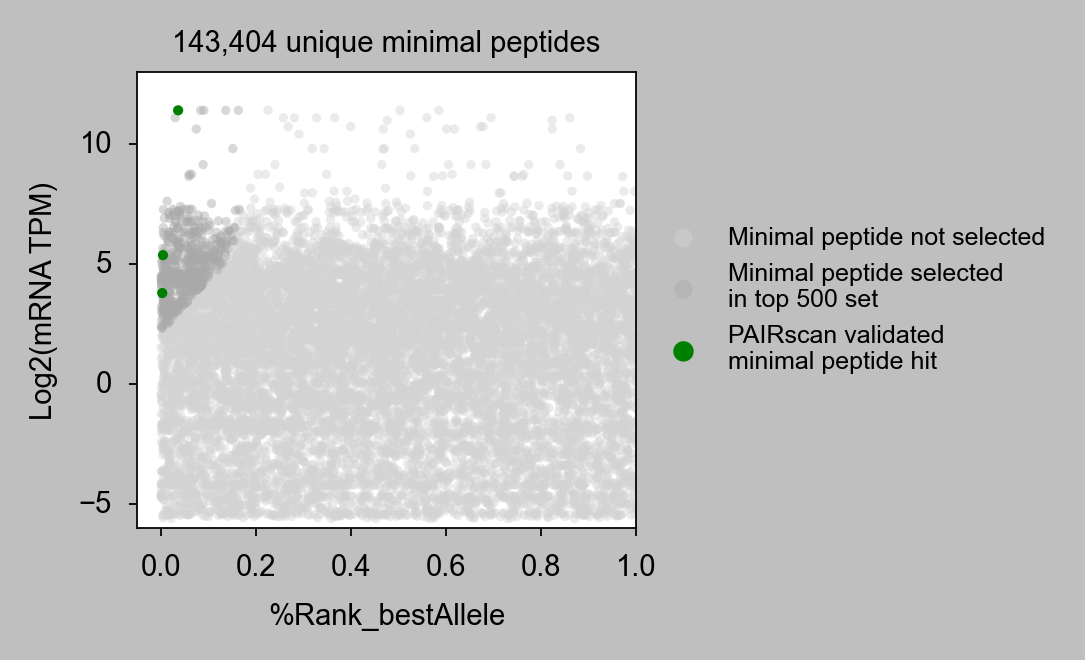

In [ ]:
ax, fig, gs = startfig(9.6, 6)

hit_mask = parsed_df["hit"]
top_500_mask = (~hit_mask) & (parsed_df.index < 500)
other_mask = ~(hit_mask | top_500_mask)

x = parsed_df["%Rank_bestAllele"]
y = np.log2(parsed_df["rna_tpm"])

ax.scatter(
    x[other_mask], y[other_mask],
    s=5, alpha=0.45, edgecolors="none",
    color="lightgrey",
    label="Minimal peptide not selected",
)

ax.scatter(
    x[top_500_mask], y[top_500_mask],
    s=5, alpha=0.45, edgecolors="none",
    color="darkgrey",
    label="Minimal peptide selected\nin top 500 set",
)

ax.scatter(
    x[hit_mask], y[hit_mask],
    s=6, alpha=1.0, edgecolors="none",
    color="green",
    label="PAIRscan validated\nminimal peptide hit",
)

ax.set_xlabel("%Rank_bestAllele", fontsize=7)
ax.set_ylabel("Log2(mRNA TPM)", fontsize=7)
ax.set_title("143,404 unique minimal peptides", fontsize=7)
ax.tick_params("both", labelsize=7)
ax.set_xlim(-0.05, 1.0)
ax.set_ylim(-6, 13)
ax.tick_params(top=False, right=False)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=6,
    scatterpoints=1,
    markerscale=2,
)

fig.tight_layout()
fig.savefig(
    "/v1/figures/fig_4_pdfs/percent_rank_best_allele_vs_tpm_mel-pt-d_pairscan_minimal_peptide_hit_coloring_v3.pdf"
)

In [8]:
parsed_df = parsed_df.iloc[0:500, :].copy()
# Every row is a minimal peptide and the "hit" column encodes with True or False whether it was recognized
y_onehot_test = parsed_df["hit"].to_numpy()
# Sort score is the ranking prediction score for including a minimal peptide in the top 500 set, based on MixMHCpred3.0 and mRNA 
y_score = parsed_df["sort_score"].to_numpy()

In [9]:
parsed_df.groupby("hit")["sort_score"].describe()

,count,mean,std,min,25%,50%,75%,max
hit,,,,,,,,
False,497.0,0.944665,0.020248,0.914872,0.926923,0.941908,0.960819,0.994423
True,3.0,0.970756,0.017099,0.951014,0.965674,0.980334,0.980627,0.980919


roc_auc 0.844
500
3


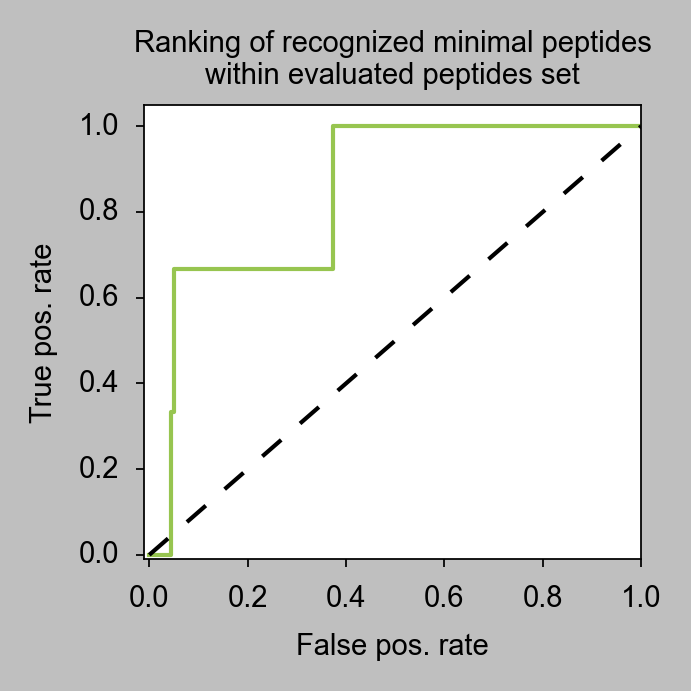

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
roc_auc = roc_auc_score(y_onehot_test, y_score)
print(f'roc_auc {roc_auc:.3f}')
print(len(y_score))
print(sum(y_onehot_test))
fpr, tpr, _ = roc_curve(y_onehot_test, y_score)
ax,fig,gs = startfig(6.26, 6.26)
ax.plot(fpr, tpr, alpha=1, label=f'computational ({roc_auc:.2f} AUC)', color="#97c550")
ax.plot([0, 1], [0, 1], color='black', linestyle='--', label=f'Random (0.50 AUC)')
ax.set_xlabel('False pos. rate', fontsize=7)
ax.set_ylabel('True pos. rate', fontsize=7)
ax.set_ylim(-0.01, 1.05)
ax.set_xlim(-0.01, 1.0)
ax.tick_params('both', labelsize = 7, top = False, right = False)
ax.set_title("Ranking of recognized minimal peptides\nwithin evaluated peptides set", fontsize = 7)
#ax.legend(fontsize = 7)
fig.tight_layout()
fig.savefig('/v1/figures/fig_4_pdfs/roc_ranking_performance_within_500_set.pdf')

#plt.close()